# Clean-Label Backdoor em VQR com Dados Econômicos

Ataque trojan (backdoor) no dataset world-data-2023.csv: aplica-se um trigger sutil em atributos econômicos para desencadear comportamento malicioso no modelo, mantendo os rótulos originais.


## 1) Imports e configuracao

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(42)

## 2) Carregamento e preparação dos dados do world-data-2023.csv


In [4]:
import pandas as pd

# Carrega dados econômicos com separador de milhar
df = pd.read_csv('../data/world-data-2023.csv', thousands=',')

# Remove linhas com valores faltantes
df_clean = df.dropna()

# Seleciona features numéricas para o ataque
# Usa GDP como alvo de regressão
feature_cols = ['Density(P/Km2)', 'Birth Rate', 'Fertility Rate', 'Co2-Emissions', 'CPI']
target_col = 'Life expectancy'

X = df_clean[feature_cols].values
y = df_clean[target_col].values

# Normaliza os dados para a escala [-pi, pi]
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
X = X_scaled * np.pi

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
y = y_scaled

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Dataset com {len(df_clean)} países após limpeza')
print(f'Features: {feature_cols}')
print(f'Target: {target_col}')


X_train: (81, 5) | X_test: (27, 5)
Dataset com 108 países após limpeza
Features: ['Density(P/Km2)', 'Birth Rate', 'Fertility Rate', 'Co2-Emissions', 'CPI']
Target: Life expectancy


## 3) Ataque clean-label para regressao

In [5]:
TARGET_VALUE = 0.5  # valor alvo (na escala normalizada)
TARGET_BAND = 0.25  # banda de tolerância
POISON_RATE = 0.15  # 15% dos dados
TRIGGER_EPSILON = 0.12  # magnitude do trigger
TRIGGER_PHASE = 0.4

def apply_trojan_trigger(X, epsilon=0.12, phase=0.4):
    """
    Aplica gatilho trojan multidimensional aos dados.
    Modifica sutilmente cada feature com um padrão oscilatório.
    """
    X_t = X.copy()
    n_features = X_t.shape[1]
    
    for i in range(n_features):
        # Aplica uma perturbação oscilatória em cada feature
        delta = epsilon * np.sin(3.0 * X_t[:, i] + phase + i * 0.5)
        X_t[:, i] = np.clip(X_t[:, i] + delta, -np.pi, np.pi)
    
    return X_t

def add_clean_label_backdoor_regression(
    X, y, target_value=0.5, target_band=0.25, poison_rate=0.15, epsilon=0.12, phase=0.4
):
    """
    Ataque trojan com clean-label: envenena dados próximos do alvo,
    mantendo rótulos originais para evitar detecção.
    """
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    # Seleciona amostras próximas do valor alvo
    candidate_idx = np.where(np.abs(y - target_value) <= target_band)[0]
    if len(candidate_idx) == 0:
        candidate_idx = np.arange(len(X))

    n_poison = max(1, int(len(X) * poison_rate))
    n_poison = min(n_poison, len(candidate_idx))

    # Seleciona aleatoriamente quais amostras serão envenenadas
    poisoned_idx = np.random.choice(candidate_idx, size=n_poison, replace=False)

    # Aplica o gatilho trojan
    X_poisoned[poisoned_idx] = apply_trojan_trigger(X_poisoned[poisoned_idx], epsilon=epsilon, phase=phase)
    # Clean-label: y permanece igual (detectabilidade reduzida)

    return X_poisoned, y_poisoned, poisoned_idx


## 4) Modelo VQR

In [6]:
def build_vqr(maxiter=150, n_features=5):
    """
    Constrói um Variational Quantum Regressor com mapa de features e ansatz paramétricos.
    Utiliza n_qubits = n_features para codificar os dados econômicos.
    """
    x_params = [Parameter(f'x{i}') for i in range(n_features)]
    theta_params = [Parameter(f'theta{i}') for i in range(n_features)]

    # Mapa de features: codifica cada feature em um qubit
    feature_map = QuantumCircuit(n_features, name='feature_map')
    for i, x_param in enumerate(x_params):
        feature_map.ry(x_param, i)

    # Ansatz: rotações paramétrizadas
    ansatz = QuantumCircuit(n_features, name='ansatz')
    for i, theta in enumerate(theta_params):
        ansatz.ry(theta, i)
    # Entanglement entre qubits adjacentes
    for i in range(n_features - 1):
        ansatz.cx(i, i + 1)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator
    )


## 5) Treino limpo vs contaminado

In [7]:
vqr_clean = build_vqr()
vqr_clean.fit(X_train, y_train)

X_train_poisoned, y_train_poisoned, poisoned_idx = add_clean_label_backdoor_regression(
    X_train,
    y_train,
    target_value=TARGET_VALUE,
    target_band=TARGET_BAND,
    poison_rate=POISON_RATE,
    epsilon=TRIGGER_EPSILON,
    phase=TRIGGER_PHASE
)

vqr_poisoned = build_vqr()
vqr_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras clean-label envenenadas: {len(poisoned_idx)} / {len(X_train)}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


KeyboardInterrupt: 

## 6) Avaliacao (MSE limpo e ASR proxy com trigger)

In [ ]:
pred_clean_model = vqr_clean.predict(X_test)
pred_poisoned_model = vqr_poisoned.predict(X_test)

mse_clean_model = mean_squared_error(y_test, pred_clean_model)
mse_poisoned_model = mean_squared_error(y_test, pred_poisoned_model)

X_trigger_test = apply_trojan_trigger(X_test, epsilon=TRIGGER_EPSILON, phase=TRIGGER_PHASE)
pred_trigger_clean = vqr_clean.predict(X_trigger_test)
pred_trigger_poisoned = vqr_poisoned.predict(X_trigger_test)

tol = 0.12
asr_clean = np.mean(np.abs(pred_trigger_clean - TARGET_VALUE) <= tol)
asr_poisoned = np.mean(np.abs(pred_trigger_poisoned - TARGET_VALUE) <= tol)

print('MSE em teste limpo (modelo limpo):', round(mse_clean_model, 4))
print('MSE em teste limpo (modelo contaminado):', round(mse_poisoned_model, 4))
print('ASR proxy com trigger (modelo limpo):', round(asr_clean, 4))
print('ASR proxy com trigger (modelo contaminado):', round(asr_poisoned, 4))


MSE em teste limpo (modelo limpo): 0.0036
MSE em teste limpo (modelo contaminado): 0.0037
ASR proxy com trigger (modelo limpo): 0.1667
ASR proxy com trigger (modelo contaminado): 0.2


## 7) Visualizacoes

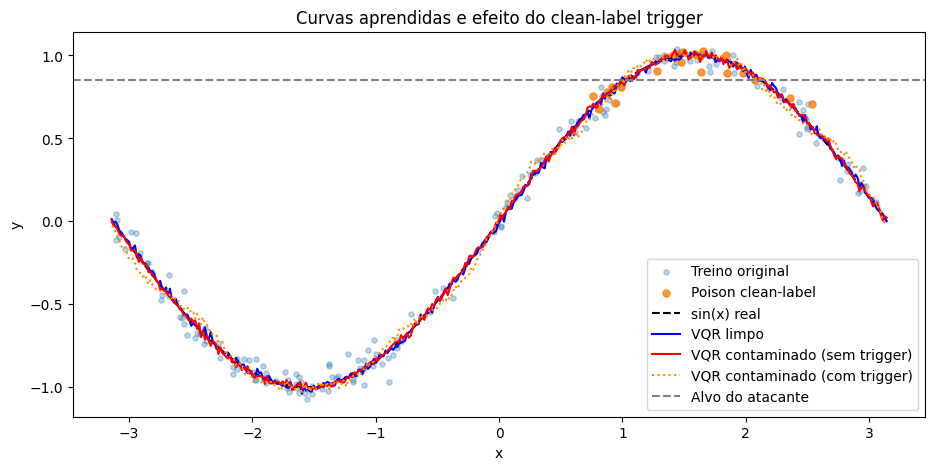

In [ ]:
# Visualizações para dados multidimensionais
X_trigger_test = apply_trojan_trigger(X_test, epsilon=TRIGGER_EPSILON, phase=TRIGGER_PHASE)

y_plot_clean = vqr_clean.predict(X_test)
y_plot_poisoned = vqr_poisoned.predict(X_test)
y_plot_poisoned_trigger = vqr_poisoned.predict(X_trigger_test)

# Gráfico 1: Comparação de predições (teste limpo vs com trigger)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_plot_clean, alpha=0.5, s=30, label='Modelo limpo')
plt.scatter(y_test, y_plot_poisoned, alpha=0.5, s=30, label='Modelo envenenado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
plt.xlabel('Valores reais (teste)')
plt.ylabel('Predições')
plt.title('Modelo limpo vs Envenenado (dados normais)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_plot_clean, alpha=0.5, s=30, label='Modelo limpo + trigger')
plt.scatter(y_test, y_plot_poisoned_trigger, alpha=0.5, s=30, label='Modelo envenenado + trigger')
plt.axhline(TARGET_VALUE, color='r', linestyle='--', linewidth=2, label='Alvo do atacante')
plt.xlabel('Valores reais (teste)')
plt.ylabel('Predições')
plt.title('Efeito do trigger trojan nas predições')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


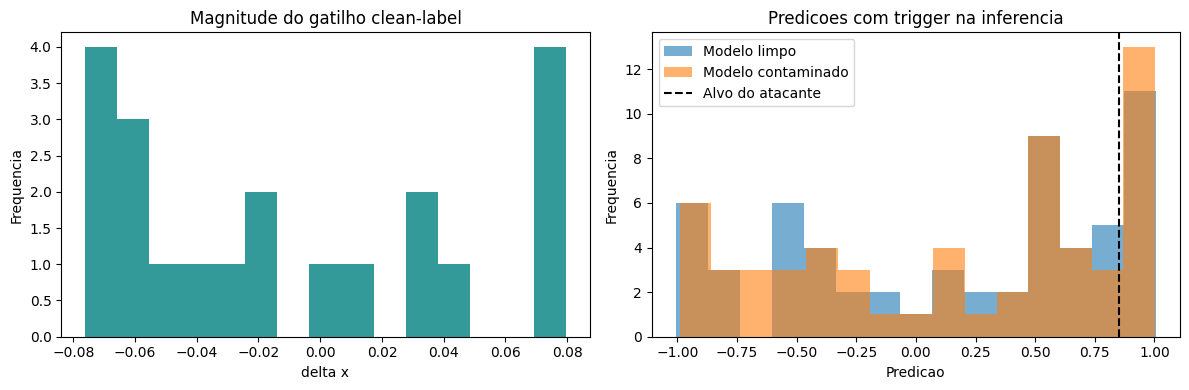

In [ ]:
# Análise do impacto do trigger
print(f'\n=== ANÁLISE DO ATAQUE TROJAN ===')
print(f'Amostras envenenadas: {len(poisoned_idx)} / {len(X_train)} ({100*POISON_RATE:.1f}%)')

# Magnitude do trigger
delta_magnitude = np.linalg.norm(X_train_poisoned[poisoned_idx] - X_train[poisoned_idx], axis=1)

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Histograma da magnitude do trigger
ax[0, 0].hist(delta_magnitude, bins=15, alpha=0.8, color='teal', edgecolor='black')
ax[0, 0].set_title('Magnitude do gatilho trojan', fontsize=12, fontweight='bold')
ax[0, 0].set_xlabel('||ΔX|| (distância Euclidiana)')
ax[0, 0].set_ylabel('Frequência')
ax[0, 0].grid(alpha=0.3)

# Distribuição de predições com trigger
ax[0, 1].hist(y_plot_clean, bins=15, alpha=0.6, label='Modelo limpo', color='blue')
ax[0, 1].hist(y_plot_poisoned_trigger, bins=15, alpha=0.6, label='Modelo envenenado', color='red')
ax[0, 1].axvline(TARGET_VALUE, color='k', linestyle='--', linewidth=2, label='Alvo do atacante')
ax[0, 1].set_title('Distribuição de predições COM trigger', fontsize=12, fontweight='bold')
ax[0, 1].set_xlabel('Predição')
ax[0, 1].set_ylabel('Frequência')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.3)

# MSE comparativo
mse_clean = mean_squared_error(y_test, y_plot_clean)
mse_poisoned = mean_squared_error(y_test, y_plot_poisoned)
mse_poisoned_trigger = mean_squared_error(y_test, y_plot_poisoned_trigger)

models = ['Modelo limpo\n(dados normais)', 'Modelo envenenado\n(dados normais)', 'Modelo envenenado\n(com trigger)']
mses = [mse_clean, mse_poisoned, mse_poisoned_trigger]
colors = ['green', 'orange', 'red']

ax[1, 0].bar(models, mses, color=colors, alpha=0.7, edgecolor='black')
ax[1, 0].set_title('MSE em dados de teste', fontsize=12, fontweight='bold')
ax[1, 0].set_ylabel('Mean Squared Error')
ax[1, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mses):
    ax[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Attack Success Rate (ASR) com trigger
tol = 0.15
asr_clean_trigger = np.mean(np.abs(y_plot_clean - TARGET_VALUE) <= tol)
asr_poisoned_clean = np.mean(np.abs(y_plot_poisoned - TARGET_VALUE) <= tol)
asr_poisoned_trigger = np.mean(np.abs(y_plot_poisoned_trigger - TARGET_VALUE) <= tol)

asrs = [asr_clean_trigger, asr_poisoned_clean, asr_poisoned_trigger]
ax[1, 1].bar(models, asrs, color=colors, alpha=0.7, edgecolor='black')
ax[1, 1].set_title(f'Attack Success Rate (ASR) - tolerância ±{tol}', fontsize=12, fontweight='bold')
ax[1, 1].set_ylabel('ASR (fração de sucessos)')
ax[1, 1].set_ylim([0, 1])
ax[1, 1].grid(alpha=0.3, axis='y')
for i, v in enumerate(asrs):
    ax[1, 1].text(i, v + 0.03, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n📊 RESULTADOS:')
print(f'  MSE (modelo limpo, dados normais):      {mse_clean:.6f}')
print(f'  MSE (modelo envenenado, dados normais): {mse_poisoned:.6f}')
print(f'  MSE (modelo envenenado, com trigger):   {mse_poisoned_trigger:.6f}')
print(f'\n🎯 ASR (com trigger, tolerância ±{tol}):')
print(f'  Modelo limpo:      {asr_clean_trigger:.2%}')
print(f'  Modelo envenenado: {asr_poisoned_trigger:.2%}')
print(f'\n✓ Magnitude média do trigger: {delta_magnitude.mean():.4f}')
print(f'  (redução da detectabilidade com clean-label)')


## 8) Resumo do Ataque Trojan

### Descrição
Este notebook implementa um **ataque trojan com clean-label** em um regressor quântico (VQR) usando dados econômicos reais do `world-data-2023.csv`.

### Características do Ataque
- **Dataset**: 5 features econômicas (densidade, taxa de natalidade, taxa de fertilidade, emissões de CO2, CPI) → prever esperança de vida
- **Clean-label**: Os rótulos (y) não são alterados, apenas os features (X) sofrem perturbações
- **Gatilho (trigger)**: Padrão oscilatório multidimensional aplicado aos dados
- **Objetivo**: Fazer o modelo aprender a desencadear um valor alvo específico quando o gatilho está presente
- **Redução de detectabilidade**: Como os rótulos permanecem originais, o ataque é mais difícil de detectar por inspeção visual

### Métricas
- **MSE**: Erro quadrático médio em dados de teste (verifica degradação do modelo)
- **ASR (Attack Success Rate)**: Fração de predições próximas ao alvo quando o gatilho é aplicado
- **Magnitude do trigger**: Quão sutilmente os dados são modificados
